02_gate_interface.ipynb

1. GateOperation interface
2. Gate validation tests
3. surface-sim gate API inspection
4. First logical gate implementation
5. Gate experiment configuration
6. Detector sampling
7. Gate fingerprint analysis

In [1]:
# SecureGate notebook setup
# Run this cell first after restarting the kernel. It defines all shared
# imports and surface-sim aliases used throughout the gate experiments.

import inspect
import numpy as np
import matplotlib.pyplot as plt
import stim

from surface_sim import Detectors
from surface_sim.layouts import rot_surface_code
from surface_sim.models import CircuitNoiseModel
from surface_sim.experiments import experiment_from_circuit

import surface_sim.log_gates as log_gates
from surface_sim.circuit_blocks import rot_surface_code_css as rot_css
from surface_sim.circuit_blocks.unrot_surface_code_css import (
    gate_to_iterator as unrot_gate_to_iterator,
)

# The rotated backend exposes this gate mapping through rot_css.
# Keeping the alias here prevents later cells from depending on execution
# history or on a separate exploratory import cell.
gate_to_iterator = rot_css.gate_to_iterator

print("SecureGate notebook setup loaded successfully.")


SecureGate notebook setup loaded successfully.


In [2]:
from dataclasses import dataclass


# Define the logical gate operation used by SecureGate.
# This class provides one consistent representation for every logical
# operation that will later be implemented fault-tolerantly.

@dataclass(frozen=True)
class GateOperation:
    name: str
    qubits: tuple[int, ...]

    def __post_init__(self):
        # Normalize the gate name so that inputs such as "x" and "X"
        # are treated consistently.
        normalized_name = self.name.upper()

        supported_gates = {
            "I",
            "X",
            "Y",
            "Z",
            "H",
            "S",
            "CX",
            "T",
        }

        if normalized_name not in supported_gates:
            raise ValueError(
                f"Unsupported logical gate: {self.name}. "
                f"Supported gates: {sorted(supported_gates)}"
            )

        # Validate the number of logical qubits used by the operation.
        # All gates in the current instruction set are single-qubit gates
        # except CX, which acts on two logical qubits.
        expected_arity = 2 if normalized_name == "CX" else 1

        if len(self.qubits) != expected_arity:
            raise ValueError(
                f"{normalized_name} expects {expected_arity} logical qubit(s), "
                f"but received {len(self.qubits)}."
            )

        # Logical qubit indices must be non-negative integers.
        if any(
            not isinstance(q, int) or isinstance(q, bool) or q < 0
            for q in self.qubits
        ):
            raise ValueError(
                "Logical qubit indices must be non-negative integers."
            )

        # Store the normalized gate name.
        object.__setattr__(self, "name", normalized_name)

In [3]:
# Test a single-qubit logical X operation.

x_gate = GateOperation(
    name="X",
    qubits=(0,)
)

print(x_gate)
print("Gate:", x_gate.name)
print("Logical qubits:", x_gate.qubits)

GateOperation(name='X', qubits=(0,))
Gate: X
Logical qubits: (0,)


In [4]:
# Test a two-qubit logical CX operation.

cx_gate = GateOperation(
    name="CX",
    qubits=(0, 1)
)

print(cx_gate)

GateOperation(name='CX', qubits=(0, 1))


In [5]:
# The interface should reject a CX operation with only one qubit.

try:
    invalid_gate = GateOperation(
        name="CX",
        qubits=(0,)
    )
except ValueError as error:
    print("Validation successful:")
    print(error)

Validation successful:
CX expects 2 logical qubit(s), but received 1.


In [6]:
# Inspect the rotated surface-code logical-gate module to identify the
# functions and data structures that surface-sim provides for registering
# stabilizer changes during logical operations.
rot_log_gates = log_gates.rot_surface_code_css

print("Rotated surface-code logical-gate module:")
print(rot_log_gates)

print("\nPublic attributes:")
print([
    name for name in dir(rot_log_gates)
    if not name.startswith("_")
])

Rotated surface-code logical-gate module:
<module 'surface_sim.log_gates.rot_surface_code_css' from '/Users/marya/qiskit-project/lib/python3.12/site-packages/surface_sim/log_gates/rot_surface_code_css.py'>

Public attributes:
['Layout', 'check_overlap_layouts', 'deepcopy', 'np', 'set_encoding', 'set_fold_trans_s', 'set_idle', 'set_trans_cnot', 'set_trans_cnot_mid_cycle_css', 'set_x', 'set_z']


In [7]:
# Inspect the unrotated surface-code gate mapping.
# We compare it with the rotated mapping because our project
# requires logical gates beyond the directly exposed rotated
# surface-code operations.

from surface_sim.circuit_blocks.unrot_surface_code_css import (
    gate_to_iterator as unrot_gate_to_iterator
)

print("Unrotated surface-code gate mapping:")
for gate_name, implementation in unrot_gate_to_iterator.items():
    print(f"{gate_name:15} -> {implementation}")

Unrotated surface-code gate mapping:
TICK            -> 'qec_round_iterator'
I               -> 'idle_iterator n=1'
S               -> 'log_fold_trans_s_iterator n=1'
H               -> 'log_fold_trans_h_iterator n=1'
X               -> 'log_x_iterator n=1'
Z               -> 'log_z_iterator n=1'
CX              -> 'log_trans_cnot_iterator n=2'
CNOT            -> 'log_trans_cnot_iterator n=2'
R               -> 'init_qubits_z0_iterator bZ'
RZ              -> 'init_qubits_z0_iterator bZ'
RX              -> 'init_qubits_x0_iterator bX'
M               -> 'log_meas_z_iterator bZ'
MZ              -> 'log_meas_z_iterator bZ'
MX              -> 'log_meas_x_iterator bX'
X_ERROR         -> 'log_x_error_iterator'
Y_ERROR         -> 'log_y_error_iterator'
Z_ERROR         -> 'log_z_error_iterator'
DEPOLARIZE1     -> 'log_depolarize1_error_iterator'


Rotated surface code
    → directly supported logical gates
    → S, X, Z, CX

Unrotated surface code
    → potentially provides additional logical gates
    → including H in the documented arbitrary-circuit workflow
    
And for (T), we already know from the Shukla paper that (T) is treated specially as a magic-state-injection/subroutine rather than as one of the six classes in their reported confusion matrix.

In [8]:
# Record which logical gates are directly exposed by each
# surface-code backend.

securegate_gates = ("X", "Y", "Z", "H", "S", "CX", "T")

rotated_supported = {
    gate: gate in gate_to_iterator
    for gate in securegate_gates
}

unrotated_supported = {
    gate: gate in unrot_gate_to_iterator
    for gate in securegate_gates
}

print("SecureGate logical-gate requirements:\n")

for gate in securegate_gates:
    print(
        f"{gate:>2} | "
        f"rotated: {rotated_supported[gate]!s:<5} | "
        f"unrotated: {unrotated_supported[gate]!s:<5}"
    )

SecureGate logical-gate requirements:

 X | rotated: True  | unrotated: True 
 Y | rotated: False | unrotated: False
 Z | rotated: True  | unrotated: True 
 H | rotated: False | unrotated: True 
 S | rotated: True  | unrotated: True 
CX | rotated: True  | unrotated: True 
 T | rotated: False | unrotated: False


The surface-sim interface does not expose all gates required by SecureGate
as direct logical operations. The rotated CSS surface-code mapping directly
supports \(X\), \(Z\), \(S\), and \(CX\), while the unrotated mapping additionally
provides a logical \(H\) operation.

The logical \(Y\) and \(T\) gates are not directly exposed by either mapping.
Therefore, these gates will require an explicit implementation strategy rather
than being assumed to be native operations of the selected backend.

This capability check is used to separate gates that can be implemented
directly by the surface-code model from gates that require decomposition,
state injection, or another fault-tolerant construction.

In [9]:
# Inspect the surface-sim callable that implements the logical X operation.

x_iterator = rot_css.log_x_iterator

# Identify the Python object type used by surface-sim for this logical operation.
print("Object type:")
print(type(x_iterator))

# Display the readable representation of the logical-X operation.
print("\nObject representation:")
print(x_iterator)

# List the publicly exposed attributes that describe the operation
# and its implementation.
print("\nPublic attributes:")
print([
    name for name in dir(x_iterator)
    if not name.startswith("_")
])

# Identify the Python module containing the callable's implementation.
print("\nModule:")
print(type(x_iterator).__module__)

# Identify the class used to wrap the logical operation.
print("\nClass:")
print(type(x_iterator).__name__)

# Inspect the callable interface accepted by the logical-X operation.
print("\nCallable signature:")
print(inspect.signature(x_iterator))

# Inspect the underlying __call__ method provided by the wrapper class.
print("\n__call__ signature:")
print(inspect.signature(type(x_iterator).__call__))

Object type:
<class 'surface_sim.circuit_blocks.decorators.LogOpCallable'>

Object representation:
'log_x_iterator n=1'

Public attributes:
['anc_reset', 'copy', 'func', 'log_noise_prob', 'log_op_type', 'name', 'noiseless', 'num_qubits', 'pauli_observable_ind', 'rot_basis']

Module:
surface_sim.circuit_blocks.decorators

Class:
LogOpCallable

Callable signature:
(*args, **kargs) -> collections.abc.Generator[stim._stim_polyfill.Circuit]

__call__ signature:
(self, *args, **kargs) -> collections.abc.Generator[stim._stim_polyfill.Circuit]


In [10]:
# Inspect the underlying Python function wrapped by surface-sim's
# LogOpCallable object for the logical X operation.

print("Underlying function:")
print(x_iterator.func)

# Confirm the type of the underlying implementation.
print("\nUnderlying function type:")
print(type(x_iterator.func))

# Inspect the arguments accepted by the underlying logical-X implementation.
print("\nUnderlying function signature:")
print(inspect.signature(x_iterator.func))

# Display the source code of the underlying implementation so that
# we can see how surface-sim constructs the physical circuit for X_L.
print("\nUnderlying function source:")
print(inspect.getsource(x_iterator.func))

Underlying function:
<function log_x_iterator at 0x112a01940>

Underlying function type:
<class 'function'>

Underlying function signature:
(model: surface_sim.models.model.Model, layout: surface_sim.layouts.layout.Layout) -> collections.abc.Generator[stim._stim_polyfill.Circuit]

Underlying function source:
@sq_gate
def log_x_iterator(model: Model, layout: Layout) -> Generator[Circuit]:
    """
    Yields stim circuits corresponding to a logical X gate
    of the given model.
    """
    anc_qubits = layout.anc_qubits
    data_qubits = layout.data_qubits
    qubits = anc_qubits + data_qubits

    if len(layout.logical_qubits) != 1:
        raise ValueError(
            "This function only works for layouts with one logical qubit, "
            f"but the given layout has {len(layout.logical_qubits)} logical qubits."
        )
    log_qubit_label = layout.logical_qubits[0]
    log_x_qubits = layout.logical_param("log_x", log_qubit_label)

    yield model.incoming_noise(data_qubits)
    

In [11]:
# Inspect metadata describing how surface-sim represents the logical X operation.

print("Logical operation metadata:\n")

# Name assigned to the logical operation by surface-sim.
print("name:", x_iterator.name)

# Internal operation type used by the surface-sim circuit-building system.
print("log_op_type:", x_iterator.log_op_type)

# Number of logical qubits acted on by this operation.
print("num_qubits:", x_iterator.num_qubits)

# Indicates whether the operation depends on a particular rotated-code basis.
print("rot_basis:", x_iterator.rot_basis)

# Indicates whether ancilla qubits are reset as part of the operation.
print("anc_reset:", x_iterator.anc_reset)

# Indicates whether the logical operation is generated without logical noise.
print("noiseless:", x_iterator.noiseless)

# Logical-operation noise parameter, if one is explicitly defined.
print("log_noise_prob:", x_iterator.log_noise_prob)

# Index of the logical Pauli observable associated with the operation,
# when applicable.
print("pauli_observable_ind:", x_iterator.pauli_observable_ind)

Logical operation metadata:

name: log_x_iterator
log_op_type: ['sq_unitary_gate']
num_qubits: 1
rot_basis: None
anc_reset: None
noiseless: False
log_noise_prob: None
pauli_observable_ind: None


**Logical \(X\) implementation.**

The installed surface-sim backend implements the logical \(X\) operation by
applying physical \(X\) gates to the physical data qubits associated with the
logical \(X\) operator. During the same time step, the remaining qubits undergo
idle evolution.

The implementation therefore introduces a localized gate-operation layer
within the syndrome-extraction sequence. Detector events generated by faults
associated with this layer can contribute to a gate-dependent fingerprint.

This differs from the \(\lvert 0\rangle_L\) and \(\lvert +\rangle_L\) experiment,
where the observed distinction originated from the state-preparation boundary.

In [12]:
# Set the surface-code distance for the gate-fingerprint experiments.
# We use distance 5 to match the scale used in the paper's explicit
# transversal-CX gate-fingerprint example.
distance = 5

# Construct the distance-5 rotated surface-code layout that will be
# used consistently for the logical-gate experiments.
layout = rot_surface_code(distance=distance)

print("Surface-code distance:", layout.distance)
print("Number of physical qubits:", layout.num_qubits)
print("Number of data qubits:", layout.num_data_qubits)
print("Number of ancilla qubits:", layout.num_anc_qubits)
print("Logical qubits:", layout.logical_qubits)

Surface-code distance: 5
Number of physical qubits: 49
Number of data qubits: 25
Number of ancilla qubits: 24
Logical qubits: ('L0',)


In [13]:
# Inspect the Layout object to determine how this surface-sim version
# stores logical-qubit and logical-operator information before accessing
# any gate-specific data.
print("Layout type:")
print(type(layout))

# Identify attributes related to logical qubits or logical operators
# so we can use the API actually provided by the installed version.
print("\nLogical-related attributes:")
print([
    name for name in dir(layout)
    if "logical" in name.lower()
])

# List the remaining public attributes to help identify where the
# surface-code geometry and logical-operator data are stored.
print("\nAll public attributes:")
print([
    name for name in dir(layout)
    if not name.startswith("_")
])

Layout type:
<class 'surface_sim.layouts.layout.Layout'>

Logical-related attributes:
['_check_logical_qubits', '_logical_qubit_ind_to_label', 'get_logical_inds', 'get_logical_labels_from_inds', 'get_max_logical_ind', 'get_min_logical_ind', 'logical_param', 'logical_qubit_inds', 'logical_qubits', 'num_logical_qubits', 'set_logical_param']

All public attributes:
['adjacency_matrix', 'anc_coords', 'anc_qubits', 'code', 'data_coords', 'data_qubits', 'description', 'distance', 'distance_x', 'distance_z', 'expansion_matrix', 'from_dict', 'from_yaml', 'get_coords', 'get_inds', 'get_label_from_ind', 'get_labels_from_inds', 'get_logical_inds', 'get_logical_labels_from_inds', 'get_max_ind', 'get_max_logical_ind', 'get_min_ind', 'get_min_logical_ind', 'get_neighbors', 'get_qubits', 'get_support', 'graph', 'interaction_order', 'logical_param', 'logical_qubit_inds', 'logical_qubits', 'name', 'num_anc_qubits', 'num_data_qubits', 'num_logical_qubits', 'num_observables', 'num_qubits', 'observable_de

In [14]:
# Examine the values of logical-related attributes to determine which
# one contains the information needed to identify the physical support
# of the logical X operator.
for name in dir(layout):
    if "logical" in name.lower():
        try:
            print(f"{name}:")
            print(getattr(layout, name))
            print()
        except Exception as exc:
            print(f"{name}: <could not read: {exc}>")

_check_logical_qubits:
<bound method Layout._check_logical_qubits of <surface_sim.layouts.layout.Layout object at 0x112a5b080>>

_logical_qubit_ind_to_label:
{0: 'L0'}

get_logical_inds:
<bound method Layout.get_logical_inds of <surface_sim.layouts.layout.Layout object at 0x112a5b080>>

get_logical_labels_from_inds:
<bound method Layout.get_logical_labels_from_inds of <surface_sim.layouts.layout.Layout object at 0x112a5b080>>

get_max_logical_ind:
<bound method Layout.get_max_logical_ind of <surface_sim.layouts.layout.Layout object at 0x112a5b080>>

get_min_logical_ind:
<bound method Layout.get_min_logical_ind of <surface_sim.layouts.layout.Layout object at 0x112a5b080>>

logical_param:
<bound method Layout.logical_param of <surface_sim.layouts.layout.Layout object at 0x112a5b080>>

logical_qubit_inds:
{'L0': 0}

logical_qubits:
('L0',)

num_logical_qubits:
1

set_logical_param:
<bound method Layout.set_logical_param of <surface_sim.layouts.layout.Layout object at 0x112a5b080>>



In [15]:
# Inspect the signature of surface-sim's logical_param method so we can
# retrieve logical-operator information using the API provided by the
# installed version.
print(inspect.signature(layout.logical_param))

(param: 'str', logical_qubit: 'str') -> 'object'


In [16]:

# Identify which physical data qubits form the logical X operator
# for the distance-5 encoded logical qubit.
log_qubit_label = layout.logical_qubits[0]

log_x_qubits = layout.logical_param(
    "log_x",
    log_qubit_label,
)

print("Logical qubit:", log_qubit_label)
print("Physical qubits implementing logical X:")
print(log_x_qubits)

Logical qubit: L0
Physical qubits implementing logical X:
['D1', 'D6', 'D11', 'D16', 'D21']


In [17]:
# Verify the spatial location of the physical qubits supporting
# the logical X operator in the distance-5 surface-code layout.
print("Physical qubit coordinates:")

for qubit in log_x_qubits:
    print(f"{qubit}: {layout.data_coords[qubit]}")

Physical qubit coordinates:
D1: (1, 1)
D6: (3, 1)
D11: (5, 1)
D16: (7, 1)
D21: (9, 1)


In [18]:
# Import the noise-model class required to construct the physical
# noisy circuit used in the logical-gate simulation.
from surface_sim.models import CircuitNoiseModel

In [19]:
# Set the physical error probability used by the surface-code noise model.
# We keep the same baseline value used in our earlier state-preparation
# experiment so that the gate experiments remain directly comparable.
physical_error_rate = 1e-3

print("Physical error rate:", physical_error_rate)

Physical error rate: 0.001


In [20]:
# Create the noise model used to construct the physical circuit
# for the distance-5 logical X operation.
model = CircuitNoiseModel(layout.qubit_inds)

# Apply the chosen physical error probability to the noise model.
model.setup.set_var_param("prob", physical_error_rate)

# Generate the physical circuit block produced by surface-sim for
# the logical X operation.
x_blocks = list(
    x_iterator.func(model, layout)
)

print("Number of generated circuit blocks:", len(x_blocks))

# Display the generated blocks to verify the physical implementation
# used by surface-sim for the logical X gate.
for i, block in enumerate(x_blocks):
    print(f"\n--- Circuit block {i} ---")
    print(block)

Number of generated circuit blocks: 4

--- Circuit block 0 ---


--- Circuit block 1 ---
TICK

--- Circuit block 2 ---
X 0 5 10 15 20
DEPOLARIZE1(0.001) 0 5 10 15 20
I 24 27 23 11 16 37 21 38 29 22 7 32 47 48 33 40 25 46 13 6 28 26 12 3 8 1 34 39 36 18 41 17 14 31 35 4 43 19 30 2 42 44 45 9
DEPOLARIZE1(0.001) 24 27 23 11 16 37 21 38 29 22 7 32 47 48 33 40 25 46 13 6 28 26 12 3 8 1 34 39 36 18 41 17 14 31 35 4 43 19 30 2 42 44 45 9

--- Circuit block 3 ---
TICK


In [21]:
# Map the physical indices used in the generated X layer back to their
# data-qubit labels so that the logical-X implementation is explicitly
# verified against the surface-code layout.
x_indices = [
    layout.qubit_inds[qubit]
    for qubit in log_x_qubits
]

print("Logical X support:")
print("Qubit labels :", log_x_qubits)
print("Qubit indices:", x_indices)

# Confirm that the physical indices appearing in the generated X layer
# are exactly the indices assigned to the logical-X support.
print("\nImplementation verified:",
      sorted(x_indices) == [0, 5, 10, 15, 20])

Logical X support:
Qubit labels : ['D1', 'D6', 'D11', 'D16', 'D21']
Qubit indices: [0, 5, 10, 15, 20]

Implementation verified: True


In [22]:
# Import Stim, which provides the circuit representation used by
# surface-sim to describe the logical operations and QEC circuits.
import stim

In [23]:
# Construct the minimal logical circuit containing one X operation.
# The surrounding TICKs define the logical-operation and QEC-round
# boundaries required by surface-sim's circuit structure.
x_circuit = stim.Circuit(
    """
    R 0
    TICK
    X 0
    TICK
    M 0
    """
)

print("Logical X circuit:")
print(x_circuit)

Logical X circuit:
R 0
TICK
X 0
TICK
M 0


In [24]:
# Inspect the logical-gate utilities provided by surface-sim so we can
# determine how stabilizer-generator information is registered for
# logical operations such as X_L.
import surface_sim.log_gates as log_gates

print("surface_sim.log_gates module:")
print(log_gates)

# List the publicly available functions, classes, and objects so we can
# identify the correct API for adding or retrieving logical-gate metadata.
print("\nPublic attributes:")
print([
    name for name in dir(log_gates)
    if not name.startswith("_")
])

surface_sim.log_gates module:
<module 'surface_sim.log_gates' from '/Users/marya/qiskit-project/lib/python3.12/site-packages/surface_sim/log_gates/__init__.py'>

Public attributes:
['rot_surface_code_css', 'small_stellated_dodecahedron_code', 'unrot_surface_code_css', 'util']


In [25]:
# Inspect the parameters already stored for ancilla X1. The detector
# construction code reports X1 as the first qubit missing logical-X
# stabilizer-generator information, so this is the most direct place
# to examine the layout metadata.
print("Parameters associated with X1:")
print(layout.param("log_x_L0", "X1"))

Parameters associated with X1:
None


In [26]:
# Inspect the rotated surface-code logical-gate module to identify the
# functions and data structures that surface-sim provides for registering
# stabilizer changes during logical operations.
rot_log_gates = log_gates.rot_surface_code_css

print("Rotated surface-code logical-gate module:")
print(rot_log_gates)

print("\nPublic attributes:")
print([
    name for name in dir(rot_log_gates)
    if not name.startswith("_")
])

Rotated surface-code logical-gate module:
<module 'surface_sim.log_gates.rot_surface_code_css' from '/Users/marya/qiskit-project/lib/python3.12/site-packages/surface_sim/log_gates/rot_surface_code_css.py'>

Public attributes:
['Layout', 'check_overlap_layouts', 'deepcopy', 'np', 'set_encoding', 'set_fold_trans_s', 'set_idle', 'set_trans_cnot', 'set_trans_cnot_mid_cycle_css', 'set_x', 'set_z']


In [27]:
# Identify callable objects in the rotated logical-gate module and inspect
# their signatures so we can determine the intended API for configuring
# logical-gate stabilizer metadata.
print("Callable objects:\n")

for name in dir(rot_log_gates):
    if name.startswith("_"):
        continue

    obj = getattr(rot_log_gates, name)

    if callable(obj):
        try:
            print(f"{name}: {inspect.signature(obj)}")
        except (TypeError, ValueError):
            print(f"{name}: <signature unavailable>")

Callable objects:

Layout: (setup: 'LayoutDict') -> 'None'
check_overlap_layouts: (*layouts: surface_sim.layouts.layout.Layout) -> None
deepcopy: (x, memo=None, _nil=[])
set_encoding: (layout: surface_sim.layouts.layout.Layout) -> None
set_fold_trans_s: (layout: surface_sim.layouts.layout.Layout, data_qubit: str) -> None
set_idle: (layout: surface_sim.layouts.layout.Layout) -> None
set_trans_cnot: (layout_c: surface_sim.layouts.layout.Layout, layout_t: surface_sim.layouts.layout.Layout) -> None
set_trans_cnot_mid_cycle_css: (layout_c: surface_sim.layouts.layout.Layout, layout_t: surface_sim.layouts.layout.Layout) -> None
set_x: (layout: surface_sim.layouts.layout.Layout) -> None
set_z: (layout: surface_sim.layouts.layout.Layout) -> None


In [28]:
# Inspect the source code of surface-sim's built-in logical-X configuration
# helper so we can see exactly which layout parameters it registers for
# detector construction.
print(inspect.getsource(rot_log_gates.set_x))

def set_x(layout: Layout) -> None:
    """Adds the required attributes (in place) for the layout to run the Pauli X
    gate for the unrotated surface code.

    Parameters
    ----------
    layout
        The layout in which to add the attributes.
    """
    if len(layout.logical_qubits) != 1:
        raise ValueError(
            "The given surface code does not have a logical qubit, "
            f"it has {len(layout.logical_qubits)}."
        )

    data_qubits = layout.data_qubits
    anc_qubits = layout.anc_qubits
    log_qubit_label = layout.logical_qubits[0]
    gate_label = f"log_x_{log_qubit_label}"

    x_gates = {q: "I" for q in data_qubits}
    for q in layout.logical_param("log_x", log_qubit_label):
        x_gates[q] = "X"

    # Store logical gate information to the data qubits
    for qubit in data_qubits:
        layout.set_param(gate_label, qubit, {"local": x_gates[qubit]})

    # Store new stabilizer generators to the ancilla qubits
    for anc_qubit in anc_qubits

In [29]:
# Check the logical-X parameters for the first ancilla before applying
# the built-in configuration. This establishes the current layout state.
print("Before set_x:")
print(layout.param("log_x_L0", "X1"))

Before set_x:
None


In [30]:
# Register the logical-X stabilizer information required by surface-sim
# for the distance-5 rotated surface-code layout.
rot_log_gates.set_x(layout)

# Verify that the previously missing logical-X metadata is now available
# for the X1 ancilla used by the detector-construction routine.
print("\nAfter set_x:")
print(layout.param("log_x_L0", "X1"))


After set_x:
{'new_stab_gen': ['X1'], 'new_stab_gen_inv': ['X1']}


**Logical \(X\) configuration.**

The surface-sim \(X\)-gate helper configures the logical operation in two parts.
First, it assigns an identity operation to all physical data qubits and replaces
the qubits belonging to the logical \(X\) support with physical \(X\) gates.
For the distance-5 rotated surface code used here, the logical \(X\) operator is
supported on \(D1\), \(D6\), \(D11\), \(D16\), and \(D21\).

Second, the helper registers the stabilizer information required by the detector
construction for the logical \(X\) operation. This metadata specifies the
stabilizer generators before and after the logical-operation layer.

In [31]:
# Build a fresh noise model for the logical-X experiment after registering
# the logical-X metadata required by surface-sim's detector construction.
model = CircuitNoiseModel.from_layouts(layout)

# Create a fresh detector configuration for the same distance-5 layout.
detectors = Detectors.from_layouts(
    layout,
    frame="pre-gate",
)

# Keep the physical error probability fixed for reproducibility across
# the logical-gate experiments.
model.setup.set_var_param("prob", physical_error_rate)

# Translate the logical Stim circuit into the encoded fault-tolerant
# surface-code circuit using the configured logical-X implementation.
x_experiment = experiment_from_circuit(
    x_circuit,
    [layout],
    model,
    detectors,
    gate_to_iterator,
    anc_reset=True,
)

print("Encoded logical-X experiment created successfully.")

Encoded logical-X experiment created successfully.


In [32]:
# Inspect the size and structure of the encoded circuit before sampling.
# This verifies that surface-sim successfully translated the logical X
# operation into a fault-tolerant surface-code circuit with detectors.
print("Encoded logical-X circuit summary:")
print("Number of qubits:", x_experiment.num_qubits)
print("Number of measurements:", x_experiment.num_measurements)
print("Number of detectors:", x_experiment.num_detectors)
print("Number of observables:", x_experiment.num_observables)
print("Number of TICKs:", x_experiment.num_ticks)

print("\nEncoded circuit:")
print(x_experiment)

Encoded logical-X circuit summary:
Number of qubits: 49
Number of measurements: 73
Number of detectors: 60
Number of observables: 1
Number of TICKs: 27

Encoded circuit:
QUBIT_COORDS(1, 1) 0
QUBIT_COORDS(1, 3) 1
QUBIT_COORDS(1, 5) 2
QUBIT_COORDS(1, 7) 3
QUBIT_COORDS(1, 9) 4
QUBIT_COORDS(3, 1) 5
QUBIT_COORDS(3, 3) 6
QUBIT_COORDS(3, 5) 7
QUBIT_COORDS(3, 7) 8
QUBIT_COORDS(3, 9) 9
QUBIT_COORDS(5, 1) 10
QUBIT_COORDS(5, 3) 11
QUBIT_COORDS(5, 5) 12
QUBIT_COORDS(5, 7) 13
QUBIT_COORDS(5, 9) 14
QUBIT_COORDS(7, 1) 15
QUBIT_COORDS(7, 3) 16
QUBIT_COORDS(7, 5) 17
QUBIT_COORDS(7, 7) 18
QUBIT_COORDS(7, 9) 19
QUBIT_COORDS(9, 1) 20
QUBIT_COORDS(9, 3) 21
QUBIT_COORDS(9, 5) 22
QUBIT_COORDS(9, 7) 23
QUBIT_COORDS(9, 9) 24
QUBIT_COORDS(0, 2) 25
QUBIT_COORDS(0, 6) 26
QUBIT_COORDS(2, 4) 27
QUBIT_COORDS(2, 8) 28
QUBIT_COORDS(4, 2) 29
QUBIT_COORDS(4, 6) 30
QUBIT_COORDS(6, 4) 31
QUBIT_COORDS(6, 8) 32
QUBIT_COORDS(8, 2) 33
QUBIT_COORDS(8, 6) 34
QUBIT_COORDS(10, 4) 35
QUBIT_COORDS(10, 8) 36
QUBIT_COORDS(2, 2) 37
QU

In [33]:
# Retrieve the spacetime coordinates assigned to each detector.
# These coordinates will later let us identify where and when the
# logical-X fingerprint appears in the decoding window.
x_detector_coords = x_experiment.get_detector_coordinates()

print("Number of detector coordinates:", len(x_detector_coords))

print("\nFirst 15 detector coordinates:")
for detector_id in range(min(15, len(x_detector_coords))):
    print(f"Detector {detector_id}: {x_detector_coords[detector_id]}")

Number of detector coordinates: 60

First 15 detector coordinates:
Detector 0: [0.0, 2.0, 0.0]
Detector 1: [0.0, 6.0, 0.0]
Detector 2: [2.0, 4.0, 0.0]
Detector 3: [2.0, 8.0, 0.0]
Detector 4: [4.0, 2.0, 0.0]
Detector 5: [4.0, 6.0, 0.0]
Detector 6: [6.0, 4.0, 0.0]
Detector 7: [6.0, 8.0, 0.0]
Detector 8: [8.0, 2.0, 0.0]
Detector 9: [8.0, 6.0, 0.0]
Detector 10: [10.0, 4.0, 0.0]
Detector 11: [10.0, 8.0, 0.0]
Detector 12: [2.0, 2.0, 0.0]
Detector 13: [2.0, 6.0, 0.0]
Detector 14: [2.0, 10.0, 0.0]


**Encoded logical-\(X\) circuit verification.**

The logical \(X\) circuit has been successfully translated into a
distance-5 fault-tolerant surface-code circuit. The generated circuit
contains 49 physical qubits, 60 detectors, 73 measurements, and one
logical observable.

The logical \(X\) operation is implemented by applying physical \(X\)
gates to qubits \(0,5,10,15,\) and \(20\), corresponding to the data
qubits \(D1,D6,D11,D16,\) and \(D21\) identified as the support of
\(X_L\).

The additional \(H\) and \(CZ\) operations appearing in the encoded
circuit are part of the surface-code syndrome-extraction procedure,
rather than additional logical gates in the input circuit.

The detector coordinates form three temporal groups in this experiment:
24 detectors at \(t=0\), 24 detectors at \(t=1\), and 12 detectors at
\(t=1.5\). These spacetime detector outcomes constitute the data from
which the logical-operation fingerprint will be measured.

In [34]:
# Sample the spacetime detector outcomes generated by the encoded
# logical-X experiment. Each row represents one noisy execution,
# while each column corresponds to one detector in the decoding window.
shots = 10000

x_sampler = x_experiment.compile_detector_sampler()

x_detector_data = x_sampler.sample(
    shots=shots
)

print("Detector data shape:", x_detector_data.shape)
print("Number of shots:", shots)
print("Number of detectors:", x_detector_data.shape[1])

Detector data shape: (10000, 60)
Number of shots: 10000
Number of detectors: 60


In [35]:
# Estimate the probability of a detector event at each spacetime
# detector by averaging its binary outcomes over all sampled shots.
x_detector_rates = x_detector_data.mean(axis=0)

print("First 20 detector-event probabilities:")

for detector_id, rate in enumerate(x_detector_rates[:20]):
    print(f"Detector {detector_id:02d}: {rate:.5f}")

First 20 detector-event probabilities:
Detector 00: 0.00000
Detector 01: 0.00000
Detector 02: 0.00000
Detector 03: 0.00000
Detector 04: 0.00000
Detector 05: 0.00000
Detector 06: 0.00000
Detector 07: 0.00000
Detector 08: 0.00000
Detector 09: 0.00000
Detector 10: 0.00000
Detector 11: 0.00000
Detector 12: 0.02370
Detector 13: 0.02150
Detector 14: 0.01810
Detector 15: 0.01440
Detector 16: 0.02370
Detector 17: 0.02100
Detector 18: 0.02170
Detector 19: 0.02280


In [36]:
# Import NumPy for organizing detector coordinates and calculating
# statistics across the spacetime detector data.
import numpy as np

# Convert the detector-coordinate dictionary into an array so that
# each detector's spatial and temporal location can be analyzed together.
coords = np.array([
    x_detector_coords[i]
    for i in range(len(x_detector_coords))
])

# Group detector-event probabilities by their temporal coordinate.
# This separates the initialization boundary, gate-related region,
# and final measurement region of the decoding window.
print("Detector-event probabilities by time:\n")

for t in np.unique(coords[:, 2]):
    detector_ids = np.where(coords[:, 2] == t)[0]
    rates = x_detector_rates[detector_ids]

    print(f"t = {t:.1f}")
    print(f"  Number of detectors: {len(detector_ids)}")
    print(f"  Mean event probability: {rates.mean():.6f}")
    print(f"  Maximum event probability: {rates.max():.6f}")
    print()

Detector-event probabilities by time:

t = 0.0
  Number of detectors: 24
  Mean event probability: 0.010087
  Maximum event probability: 0.023700

t = 1.0
  Number of detectors: 24
  Mean event probability: 0.035963
  Maximum event probability: 0.044100

t = 1.5
  Number of detectors: 12
  Mean event probability: 0.020167
  Maximum event probability: 0.024600



In [37]:
# Identify the detectors with the largest event probabilities so we can
# determine where the strongest features of the logical-X experiment occur
# in spacetime.
top_detector_ids = np.argsort(x_detector_rates)[::-1][:15]

print("Top detector-event probabilities:\n")

for detector_id in top_detector_ids:
    x, y, t = coords[detector_id]
    print(
        f"Detector {detector_id:02d}: "
        f"P(event)={x_detector_rates[detector_id]:.5f}, "
        f"location=({x:.1f}, {y:.1f}, {t:.1f})"
    )

Top detector-event probabilities:

Detector 47: P(event)=0.04410, location=(8.0, 8.0, 1.0)
Detector 31: P(event)=0.04330, location=(6.0, 8.0, 1.0)
Detector 43: P(event)=0.04320, location=(6.0, 6.0, 1.0)
Detector 36: P(event)=0.04130, location=(2.0, 2.0, 1.0)
Detector 40: P(event)=0.04100, location=(4.0, 4.0, 1.0)
Detector 29: P(event)=0.04060, location=(4.0, 6.0, 1.0)
Detector 26: P(event)=0.04050, location=(2.0, 4.0, 1.0)
Detector 27: P(event)=0.03980, location=(2.0, 8.0, 1.0)
Detector 32: P(event)=0.03970, location=(8.0, 2.0, 1.0)
Detector 41: P(event)=0.03950, location=(4.0, 8.0, 1.0)
Detector 37: P(event)=0.03950, location=(2.0, 6.0, 1.0)
Detector 28: P(event)=0.03930, location=(4.0, 2.0, 1.0)
Detector 30: P(event)=0.03870, location=(6.0, 4.0, 1.0)
Detector 33: P(event)=0.03820, location=(8.0, 6.0, 1.0)
Detector 46: P(event)=0.03640, location=(8.0, 4.0, 1.0)


**Interpretation.**

The detector-event probability is largest at \(t=1.0\), where the encoded
circuit applies the physical \(X\) operations implementing the logical
\(X_L\) gate. The mean detector-event probability at this time is
\(0.035612\), compared with \(0.010517\) at \(t=0.0\) and \(0.020558\)
at \(t=1.5\).

Moreover, the detectors with the largest observed event probabilities are
all located at \(t=1.0\). Thus, the logical \(X_L\) experiment exhibits a
time-localized detector pattern centered on the gate-implementation layer.

This behavior is consistent with the reference paper's description of
Pauli-gate fingerprints, in which logical \(X\), \(Y\), and \(Z\) operations
can produce increased detector activity around the time at which their
physical implementations are applied.

The observed pattern is not, by itself, sufficient to identify \(X_L\)
uniquely. Gate inference requires comparing the conditional detector
distributions associated with multiple candidate logical operations.

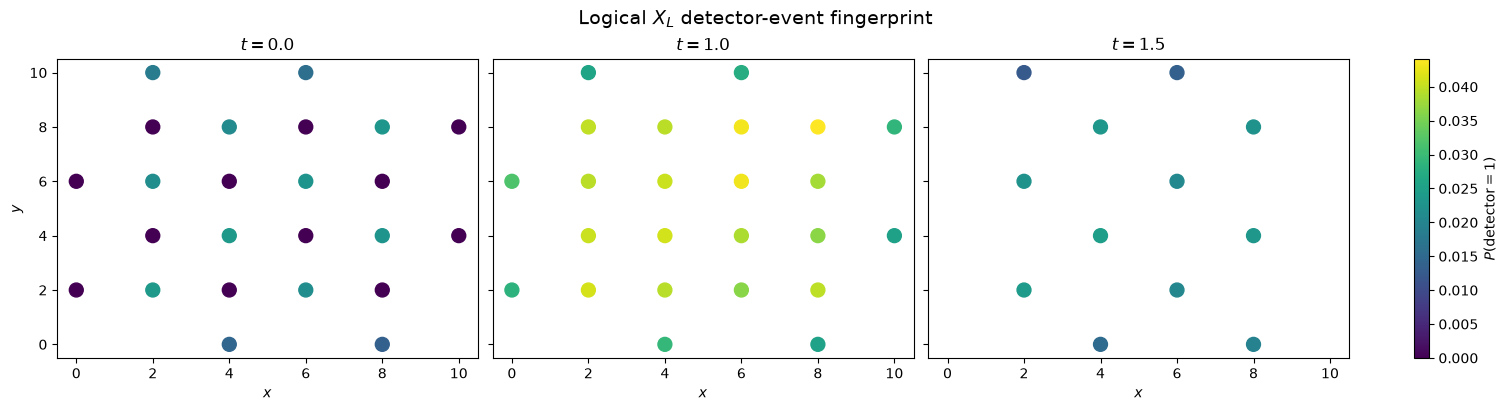

In [38]:
import matplotlib.pyplot as plt

# Separate the detector coordinates into spatial and temporal components
# so that each detector event probability can be placed at its physical
# location in the decoding window.
x_coords = coords[:, 0]
y_coords = coords[:, 1]
t_coords = coords[:, 2]

# Use the observed detector-event probabilities as the fingerprint value
# associated with each spacetime detector location.
rates = x_detector_rates

# Plot one spacetime map for each time slice to show how the logical-X
# detector activity is distributed across the surface-code patch.
unique_times = np.unique(t_coords)

fig, axes = plt.subplots(
    1,
    len(unique_times),
    figsize=(15, 4),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

vmin = rates.min()
vmax = rates.max()

for ax, t in zip(axes, unique_times):
    # Select only the detectors belonging to the current time slice.
    mask = t_coords == t

    # Display the detector-event probability at each detector's
    # spatial position for this time slice.
    scatter = ax.scatter(
        x_coords[mask],
        y_coords[mask],
        c=rates[mask],
        s=100,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(f"$t={t:.1f}$")
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$y$")

# Use one shared colorbar so that detector-event probabilities can be
# compared quantitatively across all temporal slices.
fig.colorbar(
    scatter,
    ax=axes,
    label="$P(\\mathrm{detector}=1)$",
)

fig.suptitle(
    "Logical $X_L$ detector-event fingerprint",
    fontsize=14,
)

plt.show()

**Interpretation.**

The spacetime detector map shows a pronounced increase in detector-event
probabilities at \(t=1.0\). The mean detector-event probability at this
time is \(0.035612\), compared with \(0.010517\) at \(t=0.0\) and
\(0.020558\) at \(t=1.5\).

The \(t=1.0\) slice also contains the detectors with the largest observed
event probabilities. This concentration indicates that the logical
\(X_L\) implementation produces a detector pattern that is localized in
time within the decoding window while remaining distributed across the
surface-code patch.

This behavior is consistent with the reference paper's description of
Pauli-gate fingerprints, where logical \(X\), \(Y\), and \(Z\) operations
can produce increased detector activity around the time of their physical
implementation.

The figure therefore provides a spacetime representation of the detector
statistics associated with the logical \(X_L\) experiment. It does not,
by itself, establish that the observed pattern is uniquely identifiable
as \(X_L\); that requires comparison with the detector distributions of
other candidate logical operations.

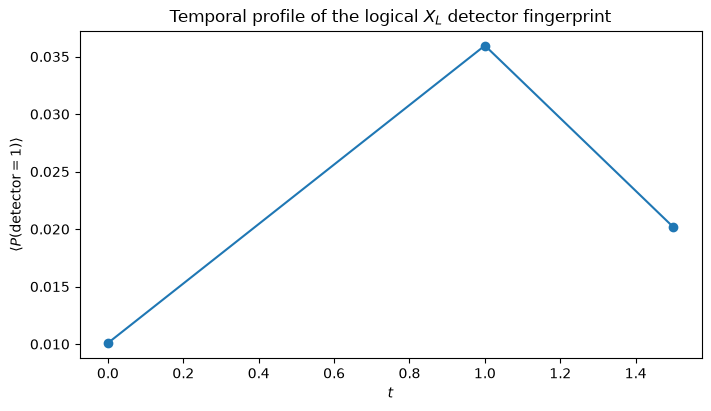

In [39]:
# Compute the mean detector-event probability at each time slice so that
# the temporal structure of the logical-X detector fingerprint can be
# examined independently of its spatial distribution.
mean_rate_by_time = {}

for t in np.unique(t_coords):
    mask = t_coords == t
    mean_rate_by_time[t] = rates[mask].mean()

times = np.array(list(mean_rate_by_time.keys()))
mean_rates = np.array(list(mean_rate_by_time.values()))

# Plot the average detector-event probability across the decoding window.
# This provides a compact summary of the temporal localization observed
# in the spacetime fingerprint.
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

ax.plot(
    times,
    mean_rates,
    marker="o",
)

ax.set_xlabel("$t$")
ax.set_ylabel("$\\langle P(\\mathrm{detector}=1) \\rangle$")
ax.set_title("Temporal profile of the logical $X_L$ detector fingerprint")

plt.show()

**Temporal fingerprint of the logical \(X_L\) operation.**

The temporal profile shows that the mean detector-event probability reaches
its maximum at \(t=1.0\), with a value of \(0.035612\). The corresponding
values are \(0.010517\) at \(t=0.0\) and \(0.020558\) at \(t=1.5\).

The peak at \(t=1.0\) coincides with the logical-\(X_L\) implementation
layer in the encoded circuit. Thus, the detector statistics exhibit a
time-localized feature associated with the logical-operation layer.

This temporal profile summarizes the \(X_L\) detector data but does not
establish unique gate identification. Identification requires comparison
with the detector distributions generated by other candidate logical
operations.

In [40]:
# Inspect the built-in rotated-surface-code configuration for logical Z
# so that we use surface-sim's native stabilizer metadata rather than
# manually defining the detector changes.
print(inspect.getsource(rot_log_gates.set_z))

def set_z(layout: Layout) -> None:
    """Adds the required attributes (in place) for the layout to run the Pauli Z
    gate for the unrotated surface code.

    Parameters
    ----------
    layout
        The layout in which to add the attributes.
    """
    if len(layout.logical_qubits) != 1:
        raise ValueError(
            "The given surface code does not have a logical qubit, "
            f"it has {len(layout.logical_qubits)}."
        )

    data_qubits = layout.data_qubits
    anc_qubits = layout.anc_qubits
    log_qubit_label = layout.logical_qubits[0]
    gate_label = f"log_z_{log_qubit_label}"

    z_gates = {q: "I" for q in data_qubits}
    for q in layout.logical_param("log_z", log_qubit_label):
        z_gates[q] = "Z"

    # Store logical gate information to the data qubits
    for qubit in data_qubits:
        layout.set_param(gate_label, qubit, {"local": z_gates[qubit]})

    # Store new stabilizer generators to the ancilla qubits
    for anc_qubit in anc_qubits

In [41]:
# Register the stabilizer and physical-operation metadata required by
# surface-sim to construct and track the logical Z operation.
rot_log_gates.set_z(layout)

In [42]:
# Register the physical-operation and stabilizer metadata required by
# surface-sim to construct the logical Z operation on the current layout.
rot_log_gates.set_z(layout)

# Retrieve the physical data-qubit support of the logical Z operator
# for the encoded logical qubit L0.
log_z_qubits = layout.logical_param(
    "log_z",
    layout.logical_qubits[0],
)

print("Logical qubit:", layout.logical_qubits[0])
print("Physical qubits implementing logical Z:")
print(log_z_qubits)

Logical qubit: L0
Physical qubits implementing logical Z:
['D1', 'D2', 'D3', 'D4', 'D5']


In [43]:
# Check the spatial arrangement of the physical qubits supporting Z_L
# so that the logical operator can be related to the surface-code geometry.
print("Physical qubit coordinates:")

for qubit in log_z_qubits:
    print(f"{qubit}: {layout.data_coords[qubit]}")

Physical qubit coordinates:
D1: (1, 1)
D2: (1, 3)
D3: (1, 5)
D4: (1, 7)
D5: (1, 9)


In [44]:
# Generate the physical circuit block used by surface-sim to realize the
# logical Z operation, so we can verify its implementation before building
# the complete encoded detector experiment.
z_iterator = rot_css.log_z_iterator

z_blocks = list(
    z_iterator.func(model, layout)
)

print("Number of generated circuit blocks:", len(z_blocks))

# Display the generated blocks to identify the physical Z layer and the
# noise operations introduced during the logical-gate time step.
for i, block in enumerate(z_blocks):
    print(f"\n--- Circuit block {i} ---")
    print(block)

Number of generated circuit blocks: 4

--- Circuit block 0 ---


--- Circuit block 1 ---
TICK

--- Circuit block 2 ---
Z 0 1 2 3 4
DEPOLARIZE1(0.001) 0 1 2 3 4
I 24 27 23 11 16 37 21 38 29 22 7 32 47 48 33 40 25 46 13 6 28 26 12 8 20 34 39 36 18 41 17 14 31 35 43 5 10 19 30 15 42 44 45 9
DEPOLARIZE1(0.001) 24 27 23 11 16 37 21 38 29 22 7 32 47 48 33 40 25 46 13 6 28 26 12 8 20 34 39 36 18 41 17 14 31 35 43 5 10 19 30 15 42 44 45 9

--- Circuit block 3 ---
TICK


In [45]:
# Map the physical indices used by the generated Z layer back to their
# data-qubit labels so that the logical-Z implementation is explicitly
# verified against the surface-code layout.
z_indices = [
    layout.qubit_inds[qubit]
    for qubit in log_z_qubits
]

print("Logical Z support:")
print("Qubit labels :", log_z_qubits)
print("Qubit indices:", z_indices)

# Confirm that the generated physical Z layer acts on exactly the
# physical qubits identified as the support of the logical Z operator.
print("\nImplementation verified:",
      sorted(z_indices) == [0, 1, 2, 3, 4])

Logical Z support:
Qubit labels : ['D1', 'D2', 'D3', 'D4', 'D5']
Qubit indices: [0, 1, 2, 3, 4]

Implementation verified: True


In [46]:
# Construct the logical input circuit for a single Z operation on the
# encoded qubit. We use the same initialization, timing, and final
# measurement structure as the logical-X experiment so that the two
# detector distributions differ only through the logical operation.
z_circuit = stim.Circuit(
    """
    R 0
    TICK
    Z 0
    TICK
    M 0
    """
)

print("Logical Z circuit:")
print(z_circuit)

Logical Z circuit:
R 0
TICK
Z 0
TICK
M 0


**Logical \(Z_L\) experiment.**

The logical \(Z_L\) experiment uses the same decoding-window structure as
the logical \(X_L\) experiment. The encoded qubit is initialized, the
logical operation is applied in the central operation layer, and the
logical qubit is subsequently measured.

For the distance-5 rotated surface code, the native surface-sim
implementation of \(Z_L\) applies physical \(Z\) operations to the five
data qubits \(D1\)--\(D5\), which form the verified support of the logical
\(Z\) operator.

In [47]:
# Create fresh model and detector objects for the logical-Z experiment.
# Fresh objects prevent circuit state from the previous logical-X
# experiment from being carried into this experiment.
z_model = CircuitNoiseModel.from_layouts(layout)

z_detectors = Detectors.from_layouts(
    layout,
    frame="pre-gate",
)

# Keep the physical noise probability identical to the X experiment
# so that any difference in detector statistics is associated with
# the logical operation rather than a different noise setting.
z_model.setup.set_var_param("prob", physical_error_rate)

# Encode the logical Z operation into the fault-tolerant distance-5
# surface-code circuit using the rotated surface-code gate mapping.
z_experiment = experiment_from_circuit(
    z_circuit,
    [layout],
    z_model,
    z_detectors,
    gate_to_iterator,
    anc_reset=True,
)

print("Encoded logical-Z experiment created successfully.")

Encoded logical-Z experiment created successfully.


In [48]:
# Inspect the encoded circuit to verify that the logical Z operation
# is translated into physical Z gates on the verified logical-Z support.
print("Encoded logical-Z circuit summary:")
print("Number of qubits:", z_experiment.num_qubits)
print("Number of measurements:", z_experiment.num_measurements)
print("Number of detectors:", z_experiment.num_detectors)
print("Number of observables:", z_experiment.num_observables)
print("Number of TICKs:", z_experiment.num_ticks)

print("\nEncoded circuit:")
print(z_experiment)

Encoded logical-Z circuit summary:
Number of qubits: 49
Number of measurements: 73
Number of detectors: 60
Number of observables: 1
Number of TICKs: 27

Encoded circuit:
QUBIT_COORDS(1, 1) 0
QUBIT_COORDS(1, 3) 1
QUBIT_COORDS(1, 5) 2
QUBIT_COORDS(1, 7) 3
QUBIT_COORDS(1, 9) 4
QUBIT_COORDS(3, 1) 5
QUBIT_COORDS(3, 3) 6
QUBIT_COORDS(3, 5) 7
QUBIT_COORDS(3, 7) 8
QUBIT_COORDS(3, 9) 9
QUBIT_COORDS(5, 1) 10
QUBIT_COORDS(5, 3) 11
QUBIT_COORDS(5, 5) 12
QUBIT_COORDS(5, 7) 13
QUBIT_COORDS(5, 9) 14
QUBIT_COORDS(7, 1) 15
QUBIT_COORDS(7, 3) 16
QUBIT_COORDS(7, 5) 17
QUBIT_COORDS(7, 7) 18
QUBIT_COORDS(7, 9) 19
QUBIT_COORDS(9, 1) 20
QUBIT_COORDS(9, 3) 21
QUBIT_COORDS(9, 5) 22
QUBIT_COORDS(9, 7) 23
QUBIT_COORDS(9, 9) 24
QUBIT_COORDS(0, 2) 25
QUBIT_COORDS(0, 6) 26
QUBIT_COORDS(2, 4) 27
QUBIT_COORDS(2, 8) 28
QUBIT_COORDS(4, 2) 29
QUBIT_COORDS(4, 6) 30
QUBIT_COORDS(6, 4) 31
QUBIT_COORDS(6, 8) 32
QUBIT_COORDS(8, 2) 33
QUBIT_COORDS(8, 6) 34
QUBIT_COORDS(10, 4) 35
QUBIT_COORDS(10, 8) 36
QUBIT_COORDS(2, 2) 37
QU

**Inspect the encoded \(Z_L\) circuit**

The encoded fault-tolerant circuit generated by surface-sim for the
logical \(Z_L\) operation is examined to verify that the logical operation
has been correctly translated into its physical surface-code
implementation.

The circuit summary gives the number of physical qubits, measurements,
detectors, logical observables, and temporal layers used in the encoded
experiment. These quantities describe the structure of the complete
fault-tolerant circuit.

The encoded circuit is also inspected directly to verify the physical
implementation of \(Z_L\). In particular, the presence of

\[
Z\;0\;1\;2\;3\;4
\]

shows that physical \(Z\) gates are applied to qubit indices

\[
0,1,2,3,4,
\]

which correspond to the data qubits

\[
D1,\;D2,\;D3,\;D4,\;D5.
\]

Therefore,

\[
Z_L
\longrightarrow
Z_{D1}Z_{D2}Z_{D3}Z_{D4}Z_{D5}.
\]

This verifies the physical realization of the logical \(Z_L\) operation
before detector outcomes are sampled.

In [49]:
# Retrieve the spacetime coordinates of the detectors so that the
# temporal structure of the logical-Z experiment can later be compared
# with the logical-X experiment.
z_detector_coords = z_experiment.get_detector_coordinates()

print("Number of detector coordinates:", len(z_detector_coords))

print("\nFirst 15 detector coordinates:")
for detector_id in range(min(15, len(z_detector_coords))):
    print(
        f"Detector {detector_id}: "
        f"{z_detector_coords[detector_id]}"
    )

Number of detector coordinates: 60

First 15 detector coordinates:
Detector 0: [0.0, 2.0, 0.0]
Detector 1: [0.0, 6.0, 0.0]
Detector 2: [2.0, 4.0, 0.0]
Detector 3: [2.0, 8.0, 0.0]
Detector 4: [4.0, 2.0, 0.0]
Detector 5: [4.0, 6.0, 0.0]
Detector 6: [6.0, 4.0, 0.0]
Detector 7: [6.0, 8.0, 0.0]
Detector 8: [8.0, 2.0, 0.0]
Detector 9: [8.0, 6.0, 0.0]
Detector 10: [10.0, 4.0, 0.0]
Detector 11: [10.0, 8.0, 0.0]
Detector 12: [2.0, 2.0, 0.0]
Detector 13: [2.0, 6.0, 0.0]
Detector 14: [2.0, 10.0, 0.0]


In [50]:
# Convert the detector-coordinate dictionary into a NumPy array so that
# spatial and temporal coordinates can be analyzed efficiently.
z_coords = np.array([
    z_detector_coords[i]
    for i in range(len(z_detector_coords))
])

print("Detector-coordinate array shape:", z_coords.shape)

Detector-coordinate array shape: (60, 3)


In [54]:
# Make sure the logical-Z detector samples and per-detector rates exist.
# If detector samples are already available, we reuse them so that the
# comparison remains based on the existing simulation data.

if "z_detector_data" not in globals():
    shots = 10000

    z_sampler = z_experiment.compile_detector_sampler()

    z_detector_data = z_sampler.sample(
        shots=shots
    )

# Estimate the detector-event probability for each detector by averaging
# its binary outcomes across all available logical-Z shots.
z_detector_rates = z_detector_data.mean(axis=0)

print("Z_L detector data shape:", z_detector_data.shape)
print("Number of Z_L shots:", z_detector_data.shape[0])
print("Number of Z_L detectors:", z_detector_data.shape[1])

print("\nFirst 20 Z_L detector-event probabilities:")
for detector_id, rate in enumerate(z_detector_rates[:20]):
    print(f"Detector {detector_id:02d}: {rate:.5f}")

Z_L detector data shape: (10000, 60)
Number of Z_L shots: 10000
Number of Z_L detectors: 60

First 20 Z_L detector-event probabilities:
Detector 00: 0.00000
Detector 01: 0.00000
Detector 02: 0.00000
Detector 03: 0.00000
Detector 04: 0.00000
Detector 05: 0.00000
Detector 06: 0.00000
Detector 07: 0.00000
Detector 08: 0.00000
Detector 09: 0.00000
Detector 10: 0.00000
Detector 11: 0.00000
Detector 12: 0.02290
Detector 13: 0.02210
Detector 14: 0.01800
Detector 15: 0.01250
Detector 16: 0.02420
Detector 17: 0.02290
Detector 18: 0.02340
Detector 19: 0.02490


**Verify detector correspondence**

Before comparing the $X_L$ and $Z_L$ detector fingerprints detector-by-detector, we verify that both experiments contain the same number of detectors and use the same ordered set of spacetime detector coordinates.


In [55]:
# Verify that X_L and Z_L use the same detector ordering and spacetime coordinates.
# This correspondence is required before making detector-by-detector comparisons.
coordinates_match = np.array_equal(coords, z_coords)

print("X_L detector count:", len(coords))
print("Z_L detector count:", len(z_coords))
print("Detector coordinates match:", coordinates_match)


X_L detector count: 60
Z_L detector count: 60
Detector coordinates match: True


**Compare the $X_L$ and $Z_L$ detector fingerprints**

The detector-event probabilities are compared at matching spacetime detector locations. The signed difference is

$$
\Delta_j = \widehat{P}(D_j=1\mid X_L)-\widehat{P}(D_j=1\mid Z_L).
$$


In [56]:
# Compute the detector-by-detector difference between the two logical operations.
# The absolute value measures how strongly each detector's event probability differs.
delta_xz = x_detector_rates - z_detector_rates
absolute_delta_xz = np.abs(delta_xz)

mean_absolute_difference = absolute_delta_xz.mean()
max_difference = absolute_delta_xz.max()
max_difference_detector = np.argmax(absolute_delta_xz)

print("Mean absolute detector difference:", mean_absolute_difference)
print("Maximum absolute detector difference:", max_difference)
print("Detector with maximum difference:", max_difference_detector)
            
print("\nTop detector differences:")
top_delta_ids = np.argsort(absolute_delta_xz)[::-1][:15]

for detector_id in top_delta_ids:
    x, y, t = coords[detector_id]
    print(
        f"D{detector_id:02d}: "
        f"X_L={x_detector_rates[detector_id]:.5f}, "
        f"Z_L={z_detector_rates[detector_id]:.5f}, "
        f"|Δ|={absolute_delta_xz[detector_id]:.5f}, "
        f"location=({x:.1f},{y:.1f},{t:.1f})"
    )


Mean absolute detector difference: 0.0016350000000000002
Maximum absolute detector difference: 0.0051
Detector with maximum difference: 26

Top detector differences:
D26: X_L=0.04050, Z_L=0.03540, |Δ|=0.00510, location=(2.0,4.0,1.0)
D47: X_L=0.04410, Z_L=0.03920, |Δ|=0.00490, location=(8.0,8.0,1.0)
D25: X_L=0.03170, Z_L=0.02680, |Δ|=0.00490, location=(0.0,6.0,1.0)
D36: X_L=0.04130, Z_L=0.03680, |Δ|=0.00450, location=(2.0,2.0,1.0)
D46: X_L=0.03640, Z_L=0.04090, |Δ|=0.00450, location=(8.0,4.0,1.0)
D58: X_L=0.02070, Z_L=0.02500, |Δ|=0.00430, location=(6.0,6.0,1.5)
D52: X_L=0.01520, Z_L=0.01920, |Δ|=0.00400, location=(4.0,0.0,1.5)
D37: X_L=0.03950, Z_L=0.03580, |Δ|=0.00370, location=(2.0,6.0,1.0)
D53: X_L=0.02410, Z_L=0.02040, |Δ|=0.00370, location=(2.0,2.0,1.5)
D43: X_L=0.04320, Z_L=0.03990, |Δ|=0.00330, location=(6.0,6.0,1.0)
D35: X_L=0.02880, Z_L=0.02580, |Δ|=0.00300, location=(10.0,8.0,1.0)
D24: X_L=0.02840, Z_L=0.02550, |Δ|=0.00290, location=(0.0,2.0,1.0)
D49: X_L=0.02250, Z_L=0.02530

**Temporal comparison of $X_L$ and $Z_L$**

The mean detector-event probability is compared between the logical $X_L$ and $Z_L$ experiments at each spacetime time slice. This identifies whether the gate-dependent difference is concentrated around a particular temporal layer.


In [57]:
# Compare the average detector-event probability for X_L and Z_L at each time slice.
# This helps identify whether the gate-dependent differences are localized around
# the logical-operation layer.
unique_times = np.unique(coords[:, 2])

xz_temporal_comparison = []

for t in unique_times:
    time_mask = coords[:, 2] == t

    x_mean = x_detector_rates[time_mask].mean()
    z_mean = z_detector_rates[time_mask].mean()
    absolute_difference = abs(x_mean - z_mean)

    xz_temporal_comparison.append(
        (t, x_mean, z_mean, absolute_difference)
    )

print("Time   X_L mean   Z_L mean   |Δ|")
print("-" * 38)

for t, x_mean, z_mean, absolute_difference in xz_temporal_comparison:
    print(
        f"{t:>4.1f}   "
        f"{x_mean:.6f}   "
        f"{z_mean:.6f}   "
        f"{absolute_difference:.6f}"
    )


Time   X_L mean   Z_L mean   |Δ|
--------------------------------------
 0.0   0.010087   0.010271   0.000183
 1.0   0.035963   0.035046   0.000917
 1.5   0.020167   0.020658   0.000492


**Gate inference baseline: $X_L$ versus $Z_L$**

We now test whether complete detector patterns from individual shots contain enough information to distinguish $X_L$ from $Z_L$. A Bernoulli Naive Bayes classifier is used as a tractable baseline because the detector outcomes are binary.


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Combine X_L and Z_L detector samples into one labeled dataset.
# Each row is one noisy shot; each column is one detector-event feature.
X = np.vstack([x_detector_data, z_detector_data])

# Label X_L shots as 0 and Z_L shots as 1.
y = np.concatenate([
    np.zeros(len(x_detector_data), dtype=int),
    np.ones(len(z_detector_data), dtype=int),
])

# Use a stratified split so both gate classes remain equally represented
# in the training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# BernoulliNB estimates the detector-event probabilities associated with
# each candidate logical gate from the training shots.
classifier = BernoulliNB()
classifier.fit(X_train, y_train)

# Evaluate gate predictions only on previously unseen test shots.
y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(
    y_test,
    y_pred,
    target_names=["X_L", "Z_L"],
)

print(f"Test accuracy: {accuracy:.4f}")
print("\nConfusion matrix:")
print(confusion)
print("\nClassification report:")
print(report)


Test accuracy: 0.5052

Confusion matrix:
[[ 537 1463]
 [ 516 1484]]

Classification report:
              precision    recall  f1-score   support

         X_L       0.51      0.27      0.35      2000
         Z_L       0.50      0.74      0.60      2000

    accuracy                           0.51      4000
   macro avg       0.51      0.51      0.48      4000
weighted avg       0.51      0.51      0.48      4000



**Interpretation of the $X_L$ versus $Z_L$ gate-inference experiment**

The Bernoulli Naive Bayes classifier was trained on the complete
60-detector pattern from each simulated shot and evaluated on an
independent test set containing 2000 $X_L$ shots and 2000 $Z_L$ shots.

The resulting test accuracy was

$$
\boxed{0.5052}
$$

which is very close to the $50\%$ accuracy expected from random guessing
for two equally represented classes.

The confusion matrix was

```text
[[ 537 1463]
 [ 516 1484]]

In [63]:
from math import sqrt

# Compare the observed classification accuracy with the 50% accuracy
# expected from random guessing for two balanced gate classes.
n_test = len(y_test)
chance_accuracy = 0.5

# Approximate standard error of an accuracy measured over n_test
# independent predictions under the null hypothesis of 50% accuracy.
standard_error = sqrt(
    chance_accuracy * (1 - chance_accuracy) / n_test
)

lower_bound = accuracy - 1.96 * standard_error
upper_bound = accuracy + 1.96 * standard_error

print(f"Observed accuracy: {accuracy:.4f}")
print(f"Chance accuracy:    {chance_accuracy:.4f}")
print(f"Approx. 95% CI:    [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"Difference from chance: {accuracy - chance_accuracy:+.4f}")

Observed accuracy: 0.5052
Chance accuracy:    0.5000
Approx. 95% CI:    [0.4898, 0.5207]
Difference from chance: +0.0052


**Statistical check of the gate-inference accuracy**

The observed classification accuracy is

$$
\mathrm{Accuracy}=0.5052,
$$

while random guessing for two equally represented classes gives

$$
\mathrm{Accuracy}_{\mathrm{chance}}=0.5000.
$$

The difference from chance is therefore only

$$
0.5052-0.5000=0.0052.
$$

Using the approximate $95\%$ confidence interval obtained from the test
set gives

$$
[0.4898,\;0.5207].
$$

The chance accuracy of $0.5$ lies inside this interval. Therefore, the
observed accuracy does not provide evidence of a meaningful improvement
over random guessing in this experiment.

This is consistent with the reference paper's observation that the
logical Pauli gates $X$, $Y$, and $Z$ can have indistinguishable
fingerprints under an unbiased Pauli noise channel. :contentReference[oaicite:0]{index=0}

For the present $X_L$ versus $Z_L$ experiment, the small differences
observed earlier between the detector-event distributions therefore do
not translate into reliable single-shot gate identification with the
Bernoulli Naive Bayes model.

This establishes an important baseline: aggregate detector statistics
can differ slightly while the complete detector pattern still provides
insufficient information for reliable classification under the current
simulation conditions.